In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from src.data.preproces_dataset import TextCleanTransformer
print(tf.__version__)

2.4.0


In [4]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()


In [5]:
df = pd.read_csv("../data/raw/train.csv")
df['text_clean'] = TextCleanTransformer().fit_transform(df.text.values)

X, y = df['text_clean'], df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values

### TF Preprocessing

In [8]:
num_words = 10000
oov_token = '<OOV>'
maxlen = 150
padding = 'post'
truncating = 'post'

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(
    num_words=num_words,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' ',
    char_level=False,
    oov_token=None,
    document_count=0,
)

tokenizer.fit_on_texts(X_train)
train_sequences = tokenizer.texts_to_sequences(X_train)

train_padded = pad_sequences(
    sequences=train_sequences,
    maxlen=maxlen,
    padding=padding,
    truncating=truncating,
)

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(
    sequences=test_sequences,
    maxlen=maxlen,
    padding=padding,
    truncating=truncating,
)


print(train_padded.shape)
print(y_train.shape)
print(test_padded.shape)
print(y_test.shape)


(6090, 150)
(6090,)
(1523, 150)
(1523,)


### TF Models

In [10]:
def model_evaluate(model, epochs=20, batch_size=1000, verbose=1):
    model.compile(
               optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'],
           )

    print(model.summary())

    history = model.fit(train_padded, y_train, batch_size=batch_size, epochs=epochs,
                validation_split=0.2, verbose=verbose)

    plot_graphs(history, "accuracy")
    plot_graphs(history, "loss")

    print("\n\nEvaluate on training dataset:")
    eval_train = model.evaluate(train_padded, y_train)
    print(f"LOSS: {eval_train[0]}\t ACCURACY: {eval_train[1]}")

    print("\n\nEvaluate on testing dataset:")
    eval_test = model.evaluate(test_padded, y_test)
    print(f"LOSS: {eval_test[0]}\t ACCURACY: {eval_test[1]}")


2021-07-02 14:05:32.234004: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-07-02 14:05:32.234628: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-07-02 14:05:32.484097: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               19328     
_________________________________________________________________
dense_1 (Dense)              (None, 128)               16512     
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 65        
Total params: 44,161
Trainable params: 44,161
Non-trainable params: 0
____________________________________________________

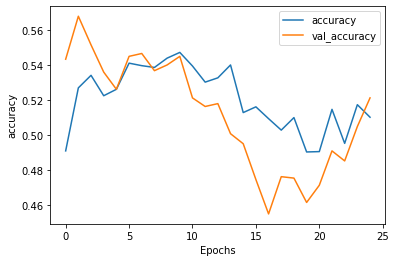

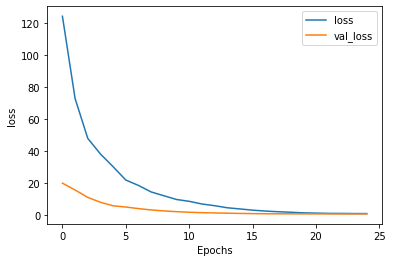

In [11]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=128, input_shape=[maxlen], activation='relu'),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_1, epochs=25, batch_size=1000)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 150, 300)          3000000   
_________________________________________________________________
dense_4 (Dense)              (None, 150, 128)          38528     
_________________________________________________________________
dropout_2 (Dropout)          (None, 150, 128)          0         
_________________________________________________________________
dense_5 (Dense)              (None, 150, 64)           8256      
_________________________________________________________________
dropout_3 (Dropout)          (None, 150, 64)           0         
_________________________________________________________________
dense_6 (Dense)              (None, 150, 1)            65        
Total params: 3,046,849
Trainable params: 3,046,849
Non-trainable params: 0
____________________________________________

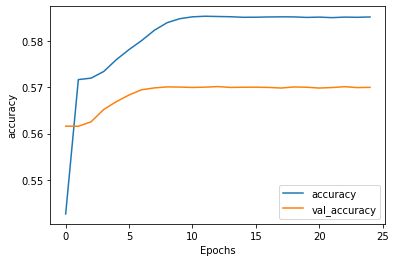

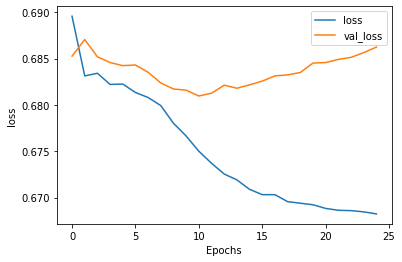

In [12]:
embedding_dim = 300
model_2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_2, epochs=25, batch_size=1000)

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
global_average_pooling1d (Gl (None, 300)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 128)               38528     
_________________________________________________________________
dropout_4 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_8 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_5 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_9 (Dense)              (None, 1)                

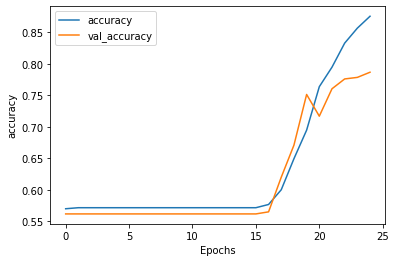

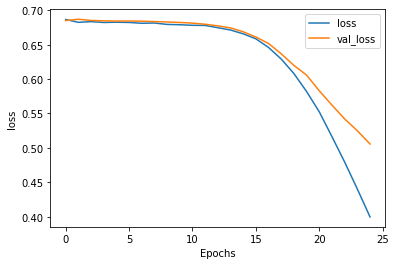

In [13]:
embedding_dim = 300
model_3 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_3, epochs=25, batch_size=1000)

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
flatten (Flatten)            (None, 45000)             0         
_________________________________________________________________
dense_10 (Dense)             (None, 128)               5760128   
_________________________________________________________________
dropout_6 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_11 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_7 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_12 (Dense)             (None, 1)                

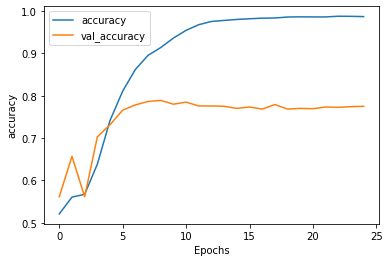

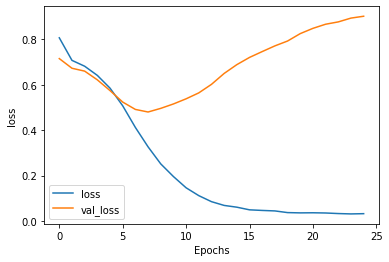

In [14]:
embedding_dim = 300
model_4 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_4, epochs=25, batch_size=1000)

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
bidirectional (Bidirectional (None, 256)               439296    
_________________________________________________________________
dense_13 (Dense)             (None, 128)               32896     
_________________________________________________________________
dropout_8 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_14 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_9 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_15 (Dense)             (None, 1)                

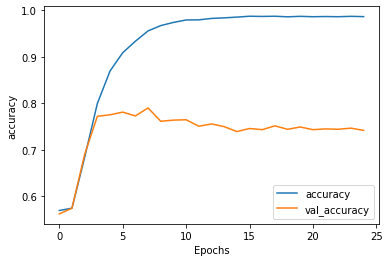

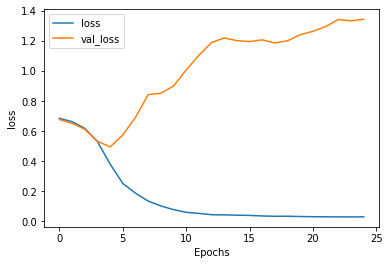

In [15]:
embedding_dim = 300
model_5 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=128)),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_5, epochs=25, batch_size=1000)

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_4 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
bidirectional_1 (Bidirection (None, 150, 128)          186880    
_________________________________________________________________
bidirectional_2 (Bidirection (None, 64)                41216     
_________________________________________________________________
dense_16 (Dense)             (None, 128)               8320      
_________________________________________________________________
dropout_10 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_17 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_11 (Dropout)         (None, 64)               

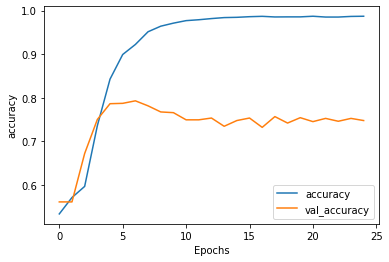

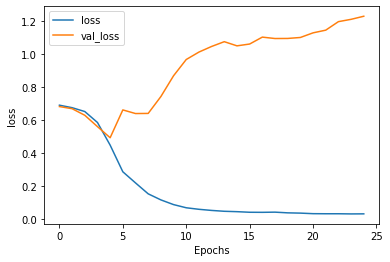

In [16]:
embedding_dim = 300
model_6 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=32)),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_6, epochs=25, batch_size=1000)

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_5 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
conv1d (Conv1D)              (None, 146, 128)          192128    
_________________________________________________________________
global_average_pooling1d_1 ( (None, 128)               0         
_________________________________________________________________
dense_19 (Dense)             (None, 128)               16512     
_________________________________________________________________
dropout_12 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_20 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_13 (Dropout)         (None, 64)               

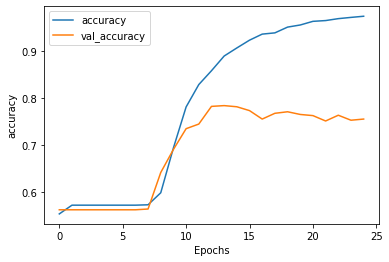

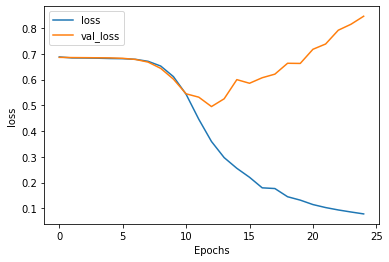

In [17]:
embedding_dim = 300
model_7 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_7, epochs=25, batch_size=1000)

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_6 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 146, 128)          192128    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 128)               16512     
_________________________________________________________________
dropout_14 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_23 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_15 (Dropout)         (None, 64)               

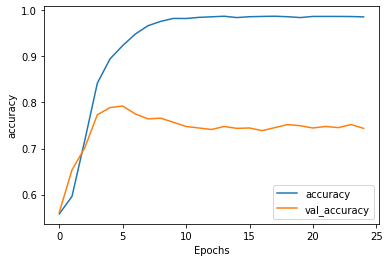

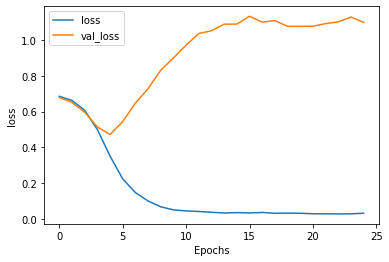

In [18]:
embedding_dim = 300
model_8 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_8, epochs=25, batch_size=1000)

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_7 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
bidirectional_3 (Bidirection (None, 128)               140544    
_________________________________________________________________
dense_25 (Dense)             (None, 128)               16512     
_________________________________________________________________
dropout_16 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_26 (Dense)             (None, 64)                8256      
_________________________________________________________________
dropout_17 (Dropout)         (None, 64)                0         
_________________________________________________________________
dense_27 (Dense)             (None, 1)                

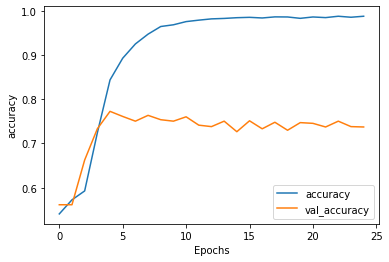

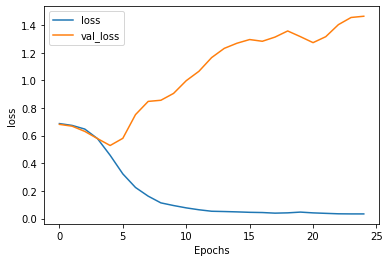

In [19]:
embedding_dim = 300
model_9 = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64)),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model_9, epochs=25, batch_size=1000)

### Overfit

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_8 (Embedding)      (None, 150, 300)          3000000   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 150, 300)          0         
_________________________________________________________________
lstm_3 (LSTM)                (None, 150, 32)           42624     
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, 150, 32)           0         
_________________________________________________________________
dense_28 (Dense)             (None, 150, 128)          4224      
_________________________________________________________________
spatial_dropout1d_2 (Spatial (None, 150, 128)          0         
_________________________________________________________________
dense_29 (Dense)             (None, 150, 1)           

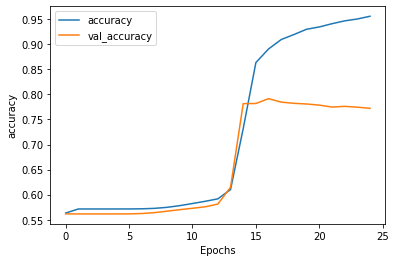

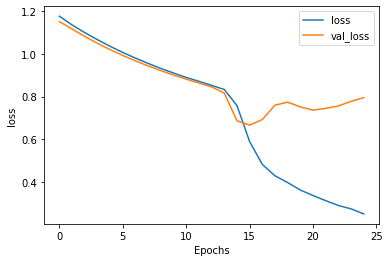

In [20]:
embedding_dim = 300
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=maxlen),
    tf.keras.layers.SpatialDropout1D(rate=0.2),
    tf.keras.layers.LSTM(units=32, return_sequences=True),

    tf.keras.layers.SpatialDropout1D(rate=0.2),
    tf.keras.layers.Dense(units=128, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.SpatialDropout1D(rate=0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_evaluate(model, epochs=25, batch_size=1000)